# EPLB Benchmark Analysis

Compare EPLB configurations across collected benchmark runs.

**Prerequisites:** Collect results with `just eplb-collect <run-name>` before running this notebook.
Each run lives in `benchmarks/eplb/<run-name>/` and contains `config.env`, `prometheus.json`, and `expert-load/` dumps.

See `benchmarks/eplb/README.md` for the full benchmark plan and execution steps.

In [1]:
%load_ext autoreload
%autoreload 2

from eplb_analysis import (
    load_run,
    load_all_runs,
    list_runs,
    metrics_comparison_table,
    stage_metrics_table,
    balancedness_comparison_table,
    plot_latency_comparison,
    plot_throughput_comparison,
    plot_throughput_timeseries,
    plot_kv_cache_usage,
    plot_balancedness_comparison,
    plot_latency_timeseries,
    plot_phase_time_comparison,
    plot_phase_time_timeseries,
    plot_pareto_frontier,
    plot_expert_load_all,
    plot_expert_load_heatmap,
    plot_rank_balance,
    plot_expert_popularity,
    plot_balancedness_over_time,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 30)

## 1. Load Runs

List available runs and load a subset for comparison. Adjust `run_names` to pick the runs you want to analyze.

In [2]:
print("Available runs:")
for name in list_runs():
    print(f"  {name}")

Available runs:
  pd-async-eplb
  pd-no-eplb


In [3]:
# Edit this list to select which runs to compare
run_names = list_runs()  # or e.g. ["pd-no-eplb", "pd-sync-eplb", "pd-async-eplb"]

runs = {name: load_run(name) for name in run_names}
print(f"Loaded {len(runs)} runs:")
for name, run in runs.items():
    expert_info = ""
    if run.expert_loads:
        n_snaps = sum(e.num_snapshots for e in run.expert_loads.values())
        expert_info = f", {n_snaps} expert snapshots"
    prom_info = "prometheus OK" if run.prometheus else "no prometheus"
    print(f"  {name}: {run.config} | {prom_info}{expert_info}")

Loaded 2 runs:
  pd-async-eplb: RunConfig('pd-async-eplb', mode=pd, eplb=async, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x4, prefill=2x1) | prometheus OK, 83 expert snapshots
  pd-no-eplb: RunConfig('pd-no-eplb', mode=pd, eplb=off, dataset=sharegpt, redundant=32, interval=3000, lws=4, decode=1x4, prefill=2x1) | prometheus OK


## 2. Metrics Overview

Summary table of Prometheus metrics across runs. Latencies in milliseconds.

In [37]:
df_metrics = metrics_comparison_table(runs)
df_metrics

,mode,eplb,dataset,redundant,interval,lws_size,decode_pods,prefill_pods,prom_duration_m,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,...,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99_ms
run,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
pd-async-eplb,pd,async,sharegpt,32,3000,4,4,2,191.250,1364.467,3029.534,6661.300,250.337,295.701,299.733,...,354.454,2191.329,5773.759,382.902,1278.225,1482.563,281.085,455426.814,476127.519,58071.538,48309.064,15399.000,14.000,0.454,470.186
pd-no-eplb,pd,off,sharegpt,32,3000,4,4,2,699.767,672.951,58979.942,76176.459,88.221,110.466,147.345,...,158.047,326.427,2357.698,210.472,876.475,1408.425,292.180,222540.521,236508.104,134814.189,119225.265,10700.000,11.000,0.286,181.877


## 3. Latency Comparison

### 3a. TTFT and ITL per concurrency stage

One group of bars per concurrency stage, one bar per run. Shows at which load level
each configuration starts to degrade.

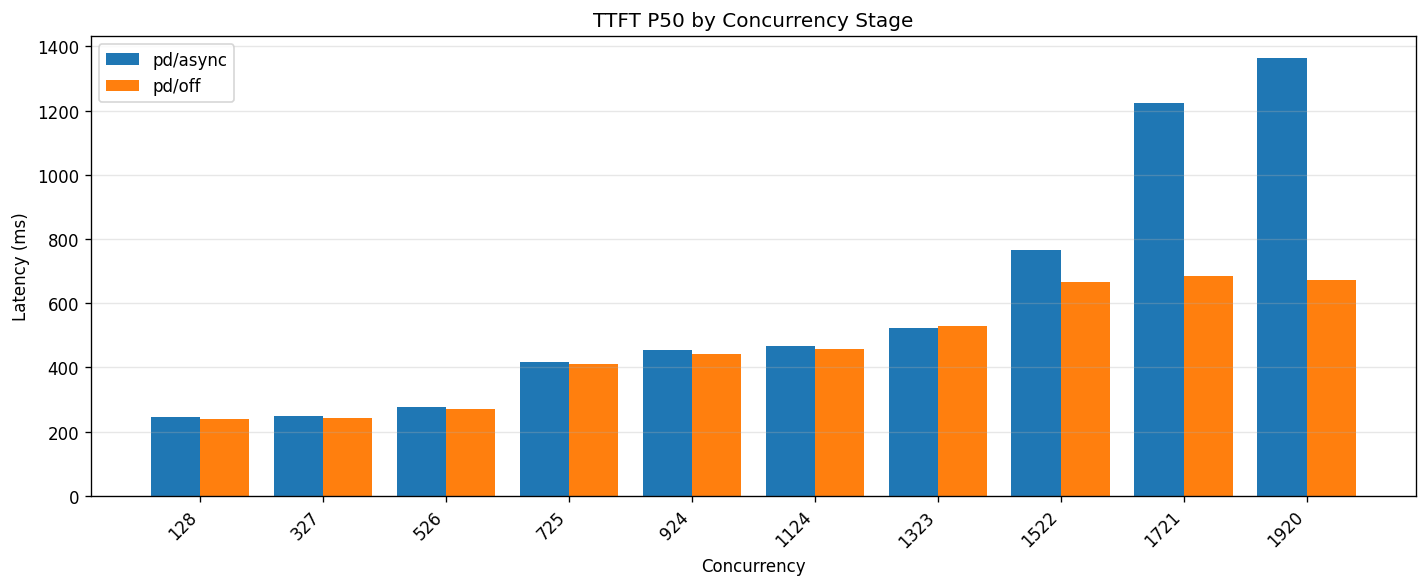

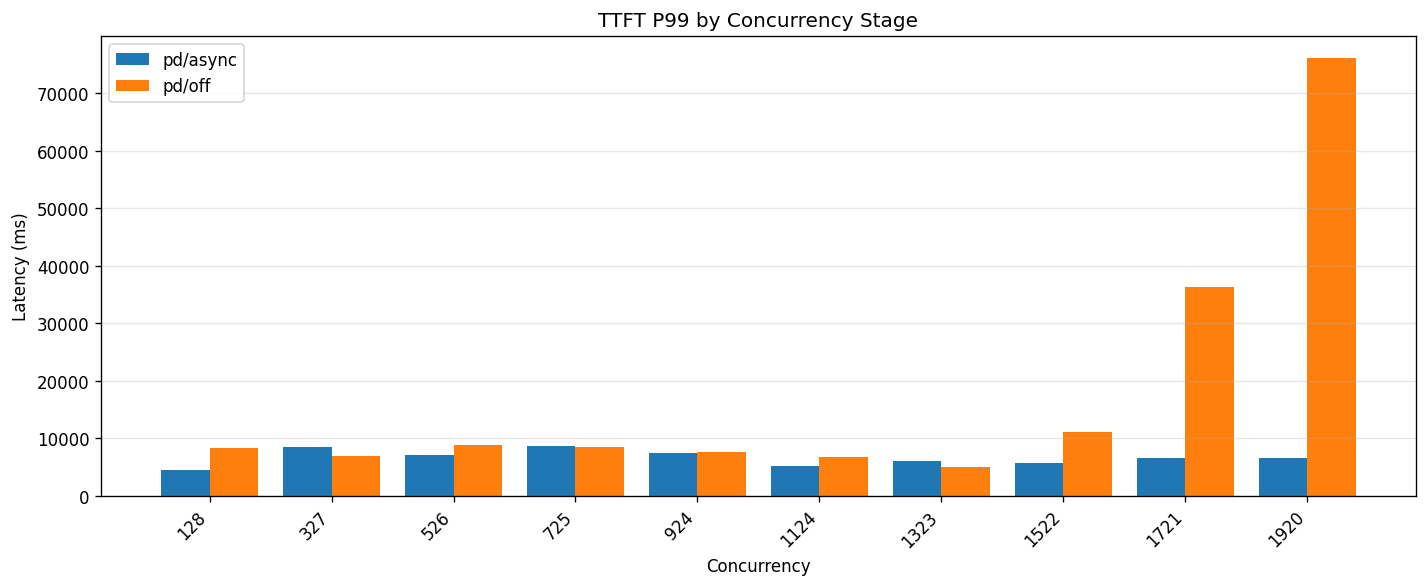

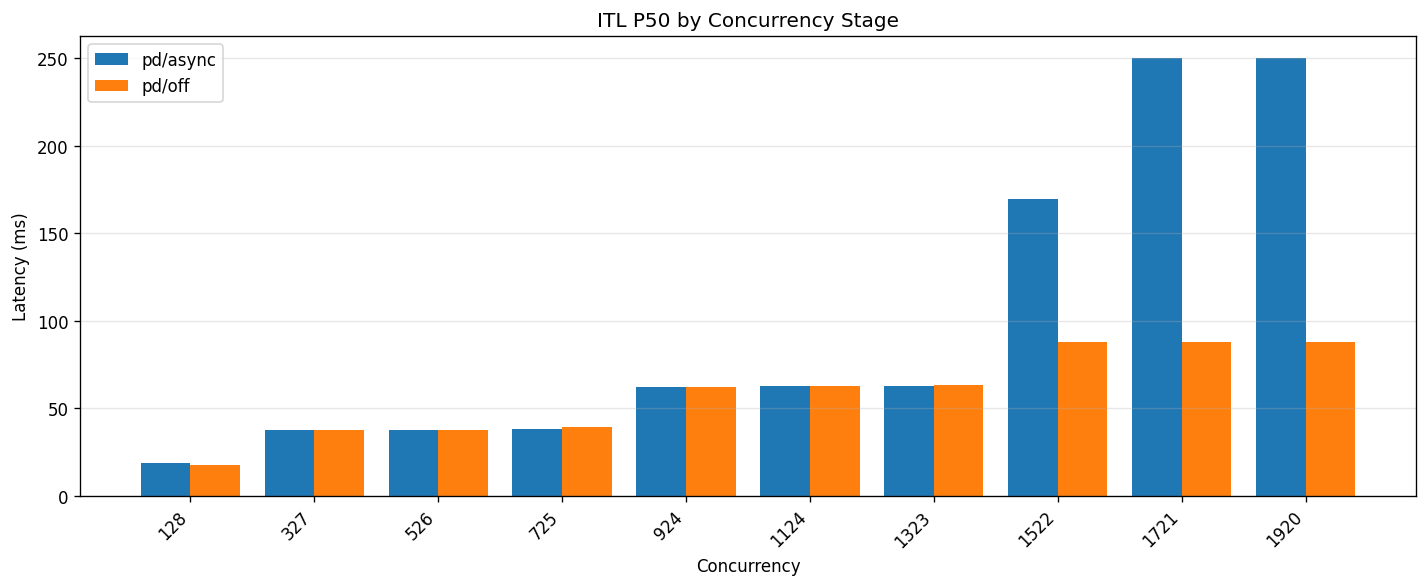

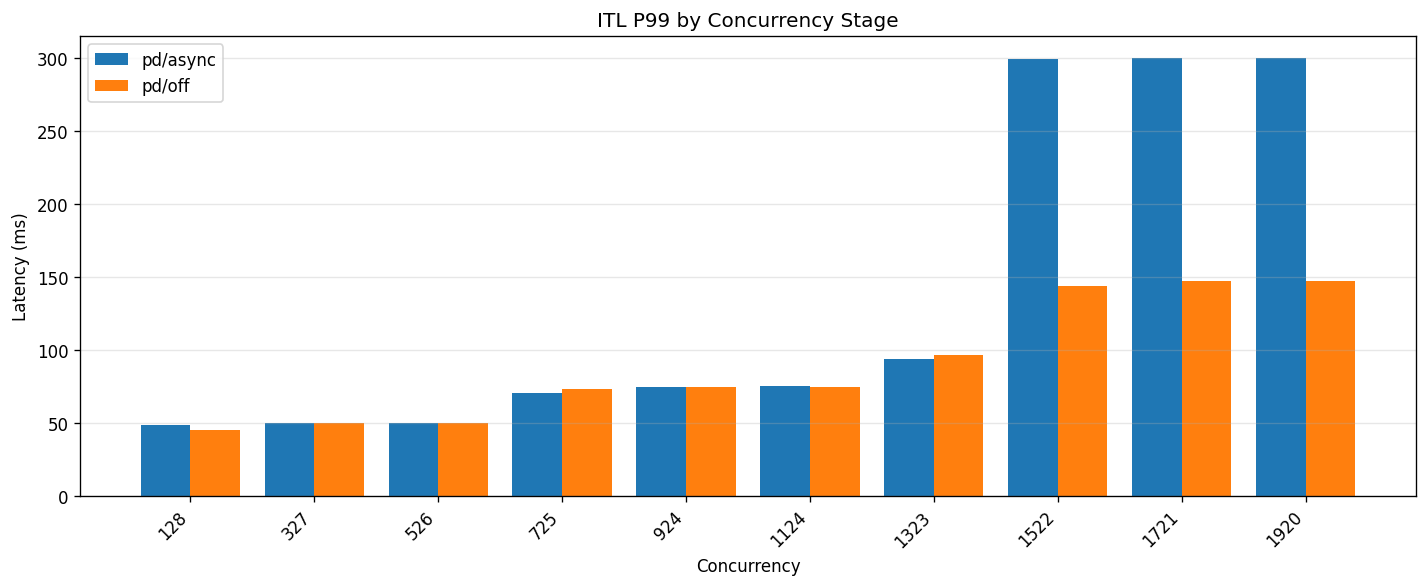

In [38]:
plot_latency_comparison(runs, metric="ttft_p50", title="TTFT P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="ttft_p99", title="TTFT P99 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p50", title="ITL P50 by Concurrency Stage")
plt.show()
plot_latency_comparison(runs, metric="itl_p99", title="ITL P99 by Concurrency Stage")
plt.show()

### 3b. Latency time series

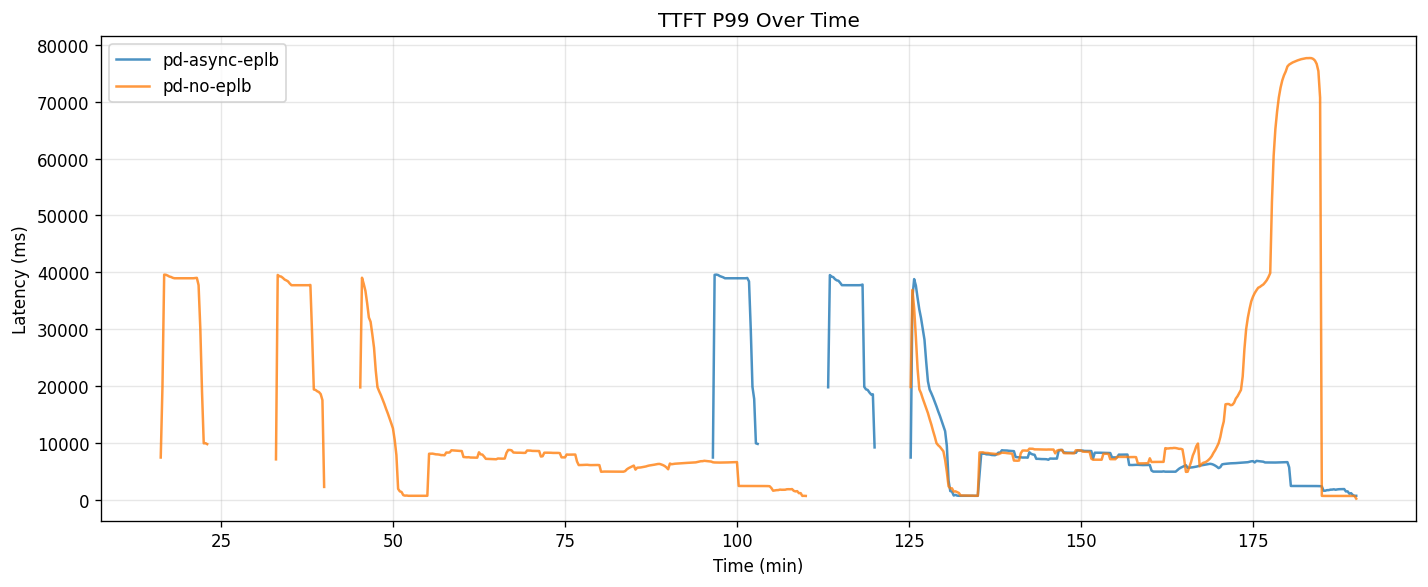

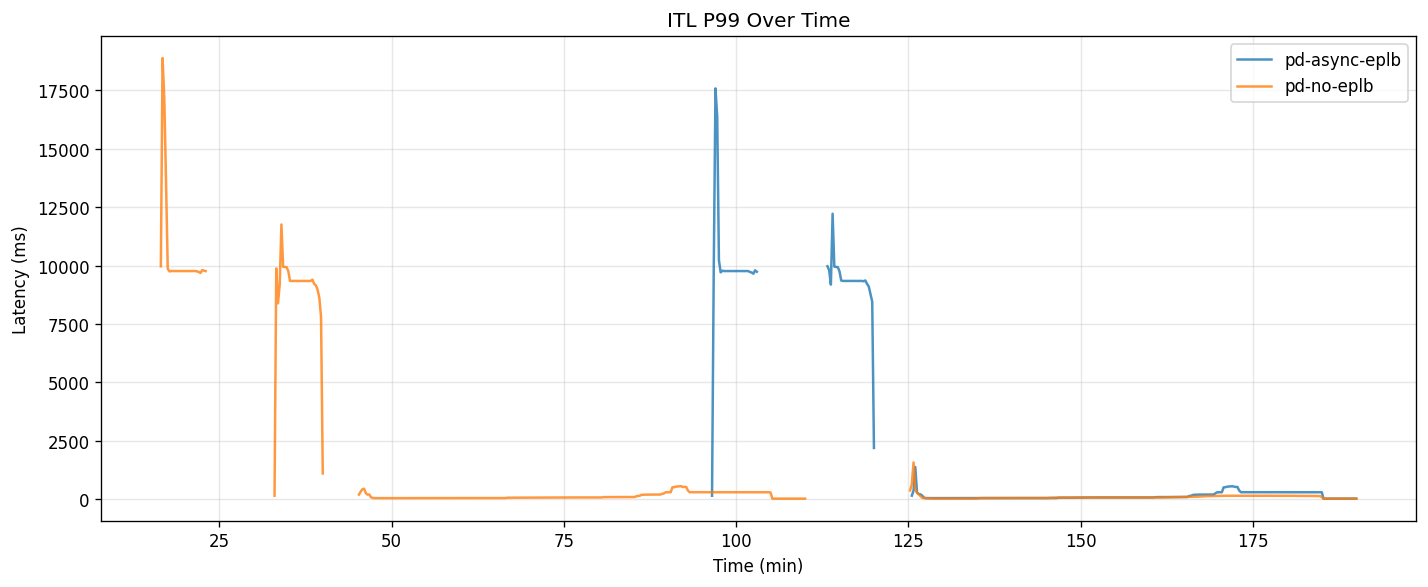

In [44]:
plot_latency_timeseries(runs, "ttft_p99_range", "TTFT P99 Over Time")
plt.show()
plot_latency_timeseries(runs, "itl_p99_range", "ITL P99 Over Time")
plt.show()

### 3c. Phase time breakdown

Where is latency spent? Prefill compute, decode compute, or queue. EPLB primarily affects decode time.

In [ ]:
plot_phase_time_comparison(runs, percentile="p99")
plt.show()
plot_phase_time_comparison(runs, percentile="p50")
plt.show()
plot_phase_time_timeseries(runs)
plt.show()

## 4. Throughput Comparison

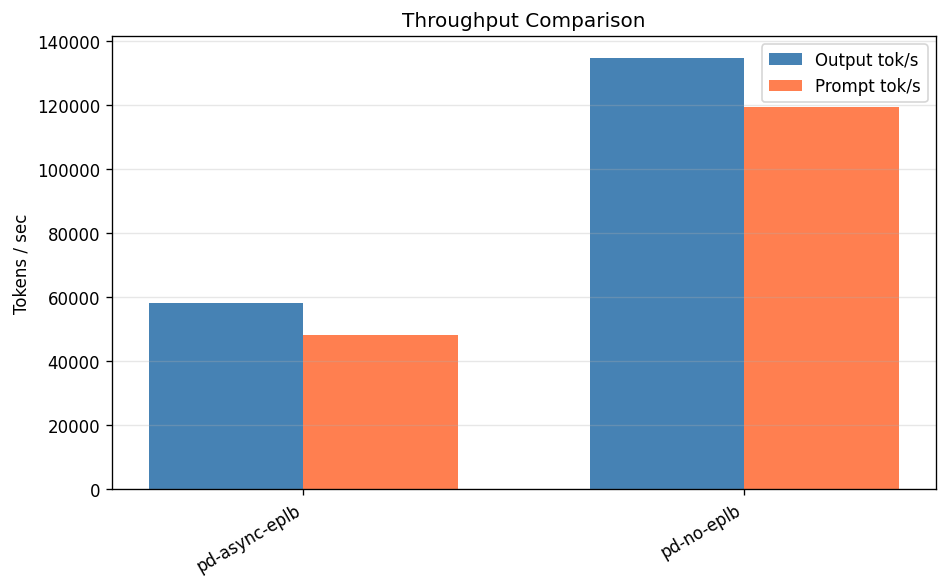

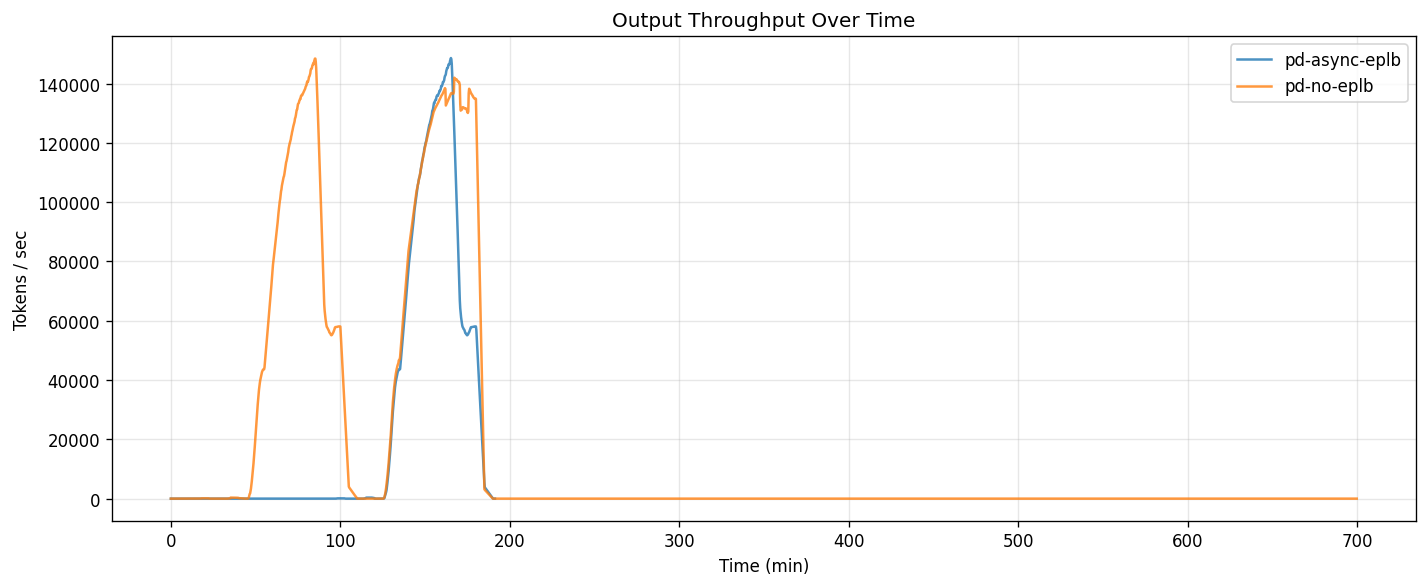

In [39]:
plot_throughput_comparison(runs)
plt.show()
plot_throughput_timeseries(runs)
plt.show()

## 4b. Throughput vs Interactivity (Pareto Frontier)

Each point is one concurrency stage. The curve shows the tradeoff: as system throughput
increases (more concurrent users), per-user output speed degrades.

Points on the upper-right frontier are optimal — you can't improve one axis without
sacrificing the other. Annotations show concurrency at each point.

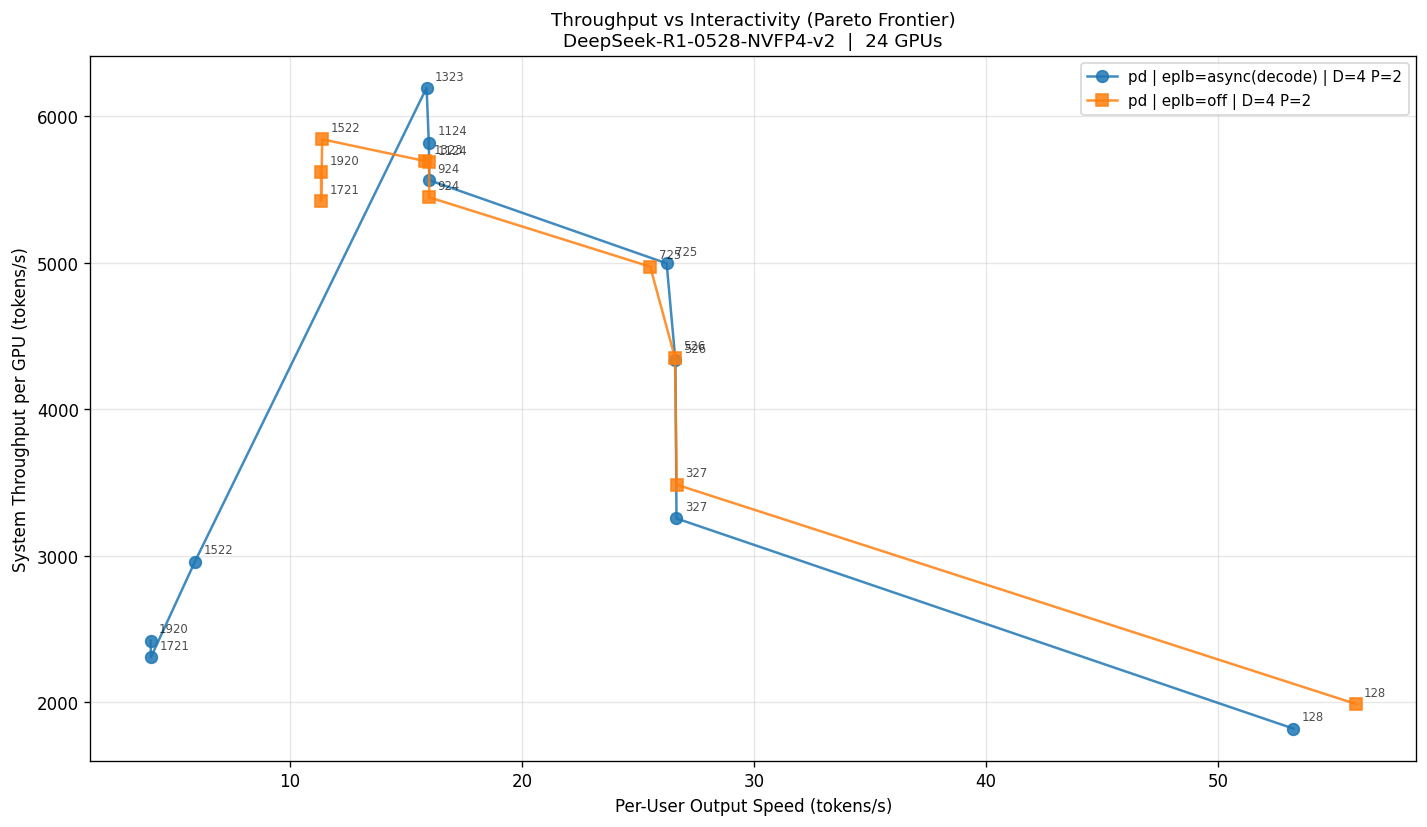


=== pd-async-eplb: per-stage metrics ===


,concurrency,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,e2e_p50_ms,e2e_p95_ms,e2e_p99_ms,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99
stage,,,,,,,,,,,,,,,,,,,,,,,,,
0,128,244.322,728.352,4436.685,18.780,41.541,48.449,1428.373,37907.463,39607.850,153.306,291.282,3207.971,158.103,310.814,1452.437,293.802,37898.505,39605.003,43665.314,68567.676,1787.000,837.000,0.039,0.048
1,327,248.217,3702.799,8588.316,37.514,48.778,49.780,3229.199,56486.937,59316.265,160.613,1178.242,6839.910,196.685,1149.119,1463.707,288.942,56232.285,59266.703,78084.441,90446.013,3553.000,633.000,0.085,0.050
2,526,275.749,2037.090,7081.648,37.581,48.903,49.910,3508.543,103754.740,116750.948,156.962,298.228,4327.965,202.620,977.628,1441.416,293.030,98469.789,115693.958,103980.291,108002.946,4936.000,794.000,0.122,0.071
3,725,416.331,3366.761,8693.750,38.122,49.932,70.208,5209.161,110506.847,118101.369,159.362,1085.224,4759.252,224.362,1128.295,1474.362,293.201,110453.836,118090.767,119853.545,119590.047,6454.000,832.000,0.163,0.073
4,924,454.427,2219.519,7492.738,62.483,73.770,74.773,4883.847,111836.434,118367.287,157.888,299.986,4719.739,246.992,1017.673,1441.060,293.375,111803.838,118360.768,133473.174,128654.274,8011.000,942.000,0.208,0.084
5,1124,468.460,1945.291,5184.707,62.572,73.888,74.894,4243.213,112693.575,118554.675,155.896,296.203,4456.113,247.928,959.465,1425.072,294.463,112669.743,118549.961,139651.171,133831.341,9331.000,921.000,0.241,0.075
6,1323,523.116,2266.410,6118.966,62.954,74.624,93.613,4382.490,112998.200,118609.420,156.221,296.821,3801.371,252.107,939.176,1408.244,293.570,112977.693,118605.347,148603.943,137530.027,10888.000,646.000,0.289,0.149
7,1522,765.397,3632.746,5783.036,169.558,259.024,299.141,4043.951,383958.529,460791.706,171.466,2510.596,4502.119,185.821,1256.459,1480.446,280.645,381577.536,460315.507,70994.826,67348.849,13192.000,501.000,0.327,0.298
8,1721,1225.388,3087.087,6606.186,250.003,295.360,299.391,4170.455,454032.258,474806.452,305.839,2213.542,5482.143,287.531,1191.551,1464.853,279.249,454032.258,474806.452,55320.930,36162.107,14625.000,609.000,0.433,0.632



=== pd-no-eplb: per-stage metrics ===


,concurrency,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,itl_p50_ms,itl_p95_ms,itl_p99_ms,e2e_p50_ms,e2e_p95_ms,e2e_p99_ms,queue_p50_ms,queue_p95_ms,queue_p99_ms,prefill_time_p50_ms,prefill_time_p95_ms,prefill_time_p99_ms,decode_time_p50_ms,decode_time_p95_ms,decode_time_p99_ms,gen_tokens_per_sec,prompt_tokens_per_sec,requests_running,requests_waiting,kv_cache_usage,nixl_xfer_p99
stage,,,,,,,,,,,,,,,,,,,,,,,,,
0,128,238.083,2744.565,8360.961,17.879,24.969,44.797,1610.141,37591.856,39539.654,158.044,506.689,7893.414,162.696,1062.928,1567.897,286.098,37582.925,39537.947,47710.656,77503.104,2662.000,0.000,0.050,0.040
1,327,243.817,2156.927,6938.844,37.500,48.756,49.756,2513.798,48240.150,49657.486,157.393,299.046,4891.021,190.304,1017.535,1433.877,289.785,48233.328,49656.159,83609.278,97162.729,4243.000,4.000,0.087,0.049
2,526,269.464,3488.079,8881.782,37.606,48.953,49.962,4203.897,101920.799,116384.160,159.957,1462.757,5573.187,196.201,1146.179,1471.067,291.268,96282.789,115256.558,104419.689,108834.759,5829.000,12.000,0.124,0.050
3,725,409.963,3339.471,8496.862,39.181,64.467,72.907,5298.165,110776.732,118155.346,159.277,1268.638,5175.876,215.962,1115.782,1461.434,291.864,110746.704,118149.341,119319.716,119068.147,7433.000,9.000,0.167,0.071
4,924,441.263,2260.122,7585.128,62.509,73.783,74.785,5411.463,112025.562,118405.112,157.887,299.984,4778.131,225.718,1030.831,1455.251,292.688,111997.358,118399.472,130677.565,126392.171,8949.000,25.000,0.202,0.075
5,1124,456.092,2103.426,6685.645,62.527,73.801,74.804,5471.771,112746.782,118560.071,157.619,299.476,4170.126,229.784,1017.464,1435.467,294.606,112727.571,118556.258,136413.411,129467.194,10228.000,318.000,0.226,0.075
6,1323,530.206,2349.498,4948.708,63.192,76.493,96.150,3915.043,186803.169,229360.634,159.094,703.934,4676.986,233.540,1062.176,1446.411,292.350,184147.986,228829.597,136615.214,127771.609,11886.000,39.000,0.277,0.099
7,1522,666.070,4862.634,11082.267,87.824,99.544,143.574,3922.571,214209.224,234841.845,156.106,296.601,2434.158,237.813,793.397,1409.470,293.550,212354.420,234470.884,140171.595,130068.545,12921.000,150.000,0.298,0.181
8,1721,685.205,21835.379,36367.076,88.185,108.554,147.301,3864.484,223606.615,236721.323,158.103,377.194,4208.559,226.768,977.708,1481.565,292.469,222765.569,236553.114,130075.629,116857.799,13282.000,90.000,0.313,0.190


In [4]:
plot_pareto_frontier(runs)
plt.show()

# Per-stage metrics table for the first run with stages
for name, run in runs.items():
    df_stages = stage_metrics_table(run)
    if df_stages is not None:
        print(f"\n=== {name}: per-stage metrics ===")
        display(df_stages)

## 5. KV Cache Usage

Important for `num_redundant_experts` sweeps -- more redundant experts consume memory that would otherwise hold KV cache.

In [ ]:
plot_kv_cache_usage(runs)
plt.show()

## 6. Expert Load Balancedness

### 6a. Cross-run balancedness comparison

In [48]:
df_bal = balancedness_comparison_table(runs)
if not df_bal.empty:
    display(df_bal)
else:
    print("No expert load data available.")

,eplb,model,snapshots,final_mean_bal,final_worst_bal,avg_mean_bal,avg_worst_bal
run,,,,,,,
pd-async-eplb,async,nvidia/DeepSeek-R1-0528-NVFP4-v2,83,0.182,0.125,0.647,0.526


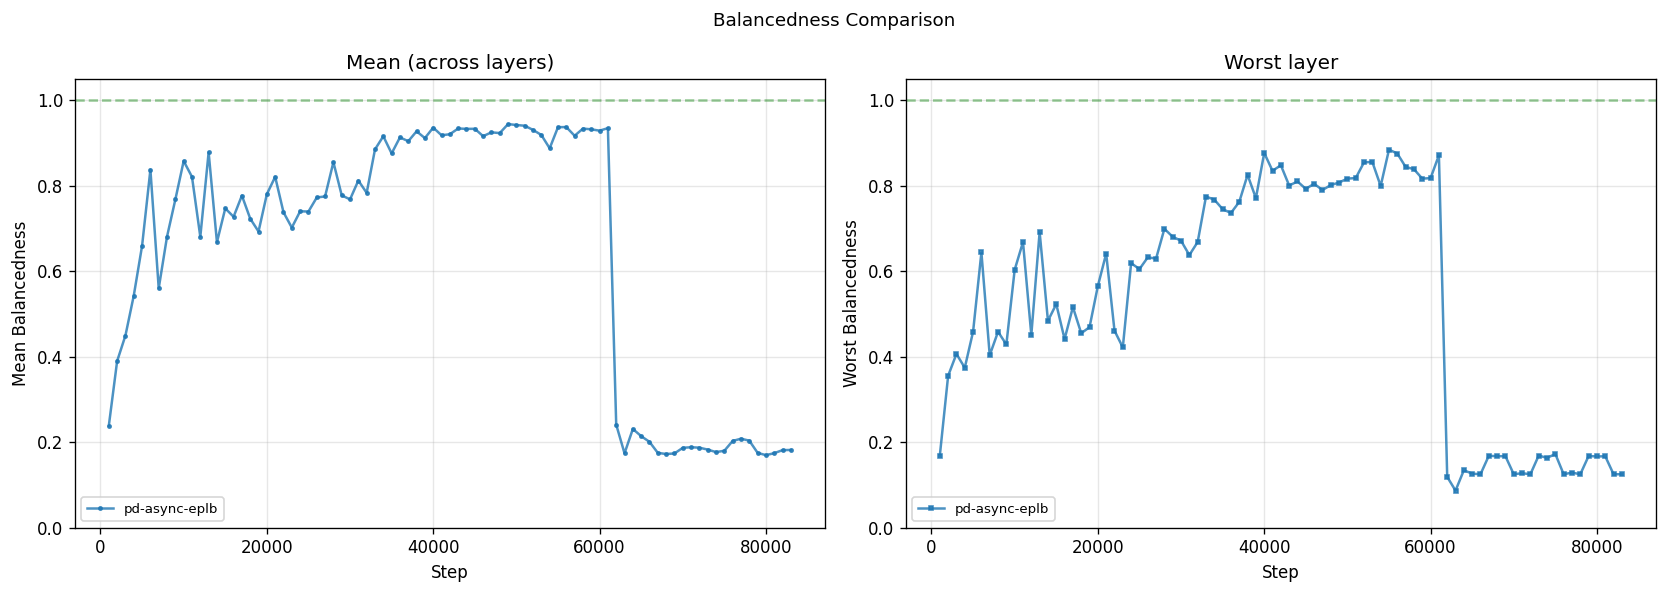

In [49]:
plot_balancedness_comparison(runs)
plt.show()

### 6b. Per-run deep dive

Select a single run to see its full expert load analysis (heatmap, rank balance, popularity, balancedness trend).

In [ ]:
# Pick a run to deep-dive (change the name here)
dive_run_name = run_names[0] if run_names else None

if dive_run_name and runs[dive_run_name].expert_loads:
    dive_run = runs[dive_run_name]
    for model_key, expert_data in dive_run.expert_loads.items():
        print(f"\n=== {dive_run_name} / {model_key} ===")
        print(f"  Model: {expert_data.model}")
        print(f"  EP width: {expert_data.world_size}")
        print(f"  Layers: {expert_data.num_layers}, Physical experts: {expert_data.num_physical}")
        print(f"  Redundant: {expert_data.num_redundant}, Per rank: {expert_data.experts_per_rank}")
        print(f"  Snapshots: {expert_data.num_snapshots}")
        plot_expert_load_all(expert_data, title_suffix=f"  [{dive_run_name}]")
        plt.show()
else:
    print(f"No expert load data for {dive_run_name}")

## 7. Phase 2: Parameter Sweep Analysis

Use these cells when comparing `num_redundant_experts` or `step_interval` sweeps. Adjust the `filter_*` calls to select the relevant runs.

In [ ]:
def filter_runs_by_prefix(runs: dict, prefix: str) -> dict:
    """Filter runs whose name starts with a prefix (e.g. 'nre-' for redundant expert sweep)."""
    return {k: v for k, v in runs.items() if k.startswith(prefix)}

# Example: num_redundant_experts sweep
nre_runs = filter_runs_by_prefix(runs, "nre-")
if nre_runs:
    print(f"num_redundant_experts sweep: {list(nre_runs.keys())}")
    plot_latency_comparison(nre_runs, title="Latency vs num_redundant_experts")
    plt.show()
    plot_throughput_comparison(nre_runs, title="Throughput vs num_redundant_experts")
    plt.show()
    plot_kv_cache_usage(nre_runs, title="KV Cache vs num_redundant_experts")
    plt.show()
    plot_balancedness_comparison(nre_runs, title="Balancedness vs num_redundant_experts")
    plt.show()
else:
    print("No nre-* runs found. Run Phase 2A sweep first.")

In [ ]:
# Example: step_interval sweep
si_runs = filter_runs_by_prefix(runs, "si-")
if si_runs:
    print(f"step_interval sweep: {list(si_runs.keys())}")
    plot_latency_comparison(si_runs, title="Latency vs step_interval")
    plt.show()
    plot_throughput_comparison(si_runs, title="Throughput vs step_interval")
    plt.show()
    plot_balancedness_comparison(si_runs, title="Balancedness vs step_interval")
    plt.show()
else:
    print("No si-* runs found. Run Phase 2B sweep first.")

In [ ]:
# Example: LWS scale sweep
lws_runs = filter_runs_by_prefix(runs, "lws-")
if lws_runs:
    print(f"LWS scale sweep: {list(lws_runs.keys())}")
    plot_latency_comparison(lws_runs, title="Latency vs LWS Size")
    plt.show()
    plot_throughput_comparison(lws_runs, title="Throughput vs LWS Size")
    plt.show()
    plot_balancedness_comparison(lws_runs, title="Balancedness vs LWS Size")
    plt.show()
else:
    print("No lws-* runs found. Run Phase 2C sweep first.")

## 8. Custom Queries

Scratch cells for ad-hoc analysis.

In [ ]:
# Example: compare two specific runs side by side
# run_a = load_run("pd-sync-eplb")
# run_b = load_run("pd-async-eplb")
# subset = {"sync": run_a, "async": run_b}
# plot_latency_comparison(subset)
# plot_throughput_comparison(subset)

In [ ]:
# Example: access raw Prometheus range data for custom plotting
# run = runs[run_names[0]]
# if run.prometheus:
#     df = run.prometheus.range_series("gen_tokens_per_sec_range")
#     if df is not None:
#         df.plot(x="time_min", y="value", title=f"{run.name} throughput")
#         plt.show()